In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df = pd.read_csv("/content/drive/MyDrive/Final Project/Raw Data/FAOSTAT_data_en_9-24-2026.csv", on_bad_lines='skip', engine='python')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22568 entries, 0 to 22567
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       22568 non-null  object 
 1   Domain            22568 non-null  object 
 2   Area Code (M49)   22568 non-null  int64  
 3   Area              22568 non-null  object 
 4   Element Code      22568 non-null  int64  
 5   Element           22568 non-null  object 
 6   Item Code (CPC)   22568 non-null  object 
 7   Item              22568 non-null  object 
 8   Year Code         22568 non-null  int64  
 9   Year              22568 non-null  int64  
 10  Unit              22568 non-null  object 
 11  Value             22280 non-null  float64
 12  Flag              22568 non-null  object 
 13  Flag Description  22568 non-null  object 
 14  Note              454 non-null    object 
dtypes: float64(1), int64(4), object(10)
memory usage: 2.6+ MB


In [10]:
df_yield = df[df['Element'] == 'Yield'].copy()

**Target & Distribution Analysis**

In [11]:
print(df_yield['Value'].describe())
print("Skewness :", df_yield['Value'].skew())

count      4626.000000
mean      13429.439083
std       14911.813561
min         152.000000
25%        2751.800000
50%        9463.050000
75%       20061.200000
max      121348.800000
Name: Value, dtype: float64
Skewness : 3.2991322849696765


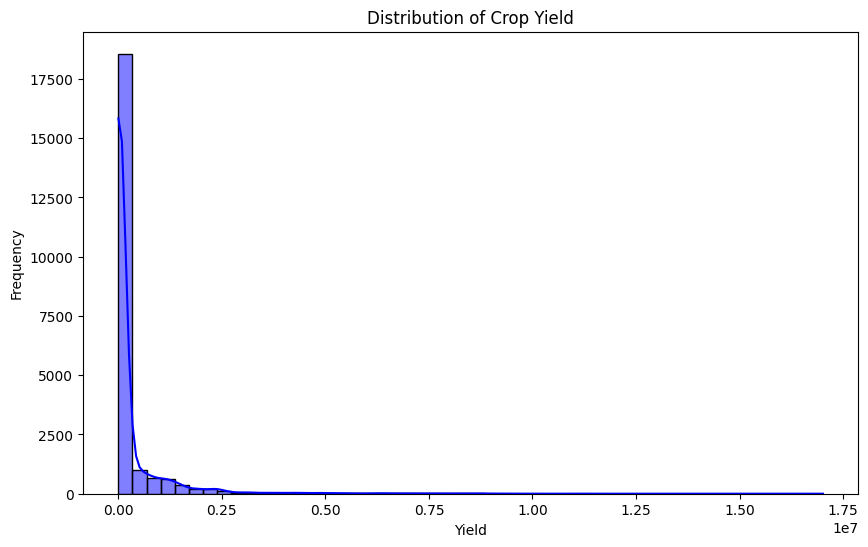

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Value'], bins=50, kde=True, color='blue')
plt.title('Distribution of Crop Yield')
plt.xlabel('Yield')
plt.ylabel('Frequency')
plt.show()

**Categorical Feature Analysis**

In [15]:
print(f"Item: {df_yield['Item'].nunique()}")
print("\nThe 5 most appearing items :")
print(df_yield['Item'].value_counts().head(5))

Item: 79

The 5 most appearing items :
Item
Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw    64
Apples                                                                       64
Apricots                                                                     64
Artichokes                                                                   64
Bananas                                                                      64
Name: count, dtype: int64


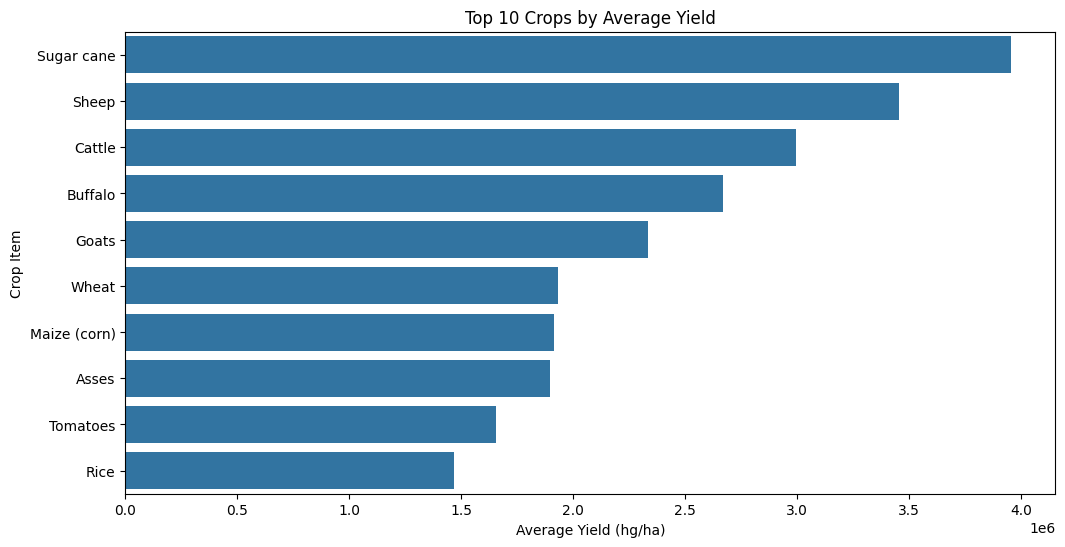

In [20]:
top_crops = df.groupby('Item')['Value'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_crops.values, y=top_crops.index)
plt.title('Top 10 Crops by Average Yield')
plt.xlabel('Average Yield (hg/ha)')
plt.ylabel('Crop Item')
plt.show()

**Univariate & Outlier Analysis**

In [21]:
Q1 = df_yield['Value'].quantile(0.25)
Q3 = df_yield['Value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_yield[(df_yield['Value'] < lower_bound) | (df_yield['Value'] > upper_bound)]
print(f"Num of outliers :  {len(outliers)} out of {len(df_yield)} revord")
print(f"Percentage:  {(len(outliers)/len(df_yield))*100:.2f}%")

Num of outliers :  101 out of 4626 revord
Percentage:  2.18%


**Bivariate Analysis**

In [22]:
top_yield_crops = df_yield.groupby('Item')['Value'].mean().sort_values(ascending=False).head(5)
print(top_yield_crops)

Item
Sugar cane                                         101300.439062
Sugar beet                                          45797.226087
Onions and shallots, dry (excluding dehydrated)     32398.331250
Bananas                                             31506.032813
Taro                                                30487.842187
Name: Value, dtype: float64


**Multivariate Analysis**

In [23]:
multi_analysis = df_yield.groupby(['Area', 'Item'])['Value'].mean().sort_values(ascending=False).head(5)
print(multi_analysis)

Area   Item                                           
Egypt  Sugar cane                                         101300.439062
       Sugar beet                                          45797.226087
       Onions and shallots, dry (excluding dehydrated)     32398.331250
       Bananas                                             31506.032813
       Taro                                                30487.842187
Name: Value, dtype: float64


**Correlation Analysis**